In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [4]:
data.dtypes


Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [5]:
data = data.iloc[:,1:]
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
#gini we are using bcz of faster computation

def gini(y):
    c, count= np.unique(y, return_counts=True)
    p = count / countssum()
    return (1 - np.sum(p ** 2))   #formula for gini

In [7]:
import numpy as np

def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return 1 - np.sum(probs ** 2)


def split(data):
    b_feature = None
    b_threshold = None
    b_gini = 999

    features = data.drop(columns=['Species']).columns
    target = data.columns[-1]

    for f in features:
        values = data[f].sort_values().unique()

        for i in range(len(values) - 1):
            t = (values[i] + values[i+1]) / 2

            left = data[data[f] <= t]
            right = data[data[f] > t]

            if len(left) == 0 or len(right) == 0:
                continue

            gini_l = gini(left[target])
            gini_r = gini(right[target])

            w_gini = (
                (len(left)/len(data)) * gini_l +
                (len(right)/len(data)) * gini_r
            )

            if w_gini < b_gini:
                b_gini = w_gini
                b_feature = f
                b_threshold = t

    return b_feature, b_threshold
split(data)

('PetalLengthCm', np.float64(2.45))

In [8]:
def b_tree(data, depth=0, max_depth=4):
    target = data.columns[-1]

    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]

    if depth >= max_depth:
        return data[target].mode()[0]

    feature, threshold = split(data)

    if feature is None:
        return data[target].mode()[0]

    left = data[data[feature] <= threshold]
    right = data[data[feature] > threshold]

    return {
        f"{feature} <= {threshold:.2f}": {
            "True": b_tree(left, depth+1, max_depth),
            "False": b_tree(right, depth+1, max_depth)
        }
    }


tree = b_tree(data)

import pprint
pprint.pprint(tree)

{'PetalLengthCm <= 2.45': {'False': {'PetalWidthCm <= 1.75': {'False': {'PetalLengthCm <= 4.85': {'False': 'Iris-virginica',
                                                                                                  'True': {'SepalLengthCm <= 5.95': {'False': 'Iris-virginica',
                                                                                                                                     'True': 'Iris-versicolor'}}}},
                                                              'True': {'PetalLengthCm <= 4.95': {'False': {'PetalWidthCm <= 1.55': {'False': 'Iris-versicolor',
                                                                                                                                    'True': 'Iris-virginica'}},
                                                                                                 'True': {'PetalWidthCm <= 1.65': {'False': 'Iris-virginica',
                                                                         

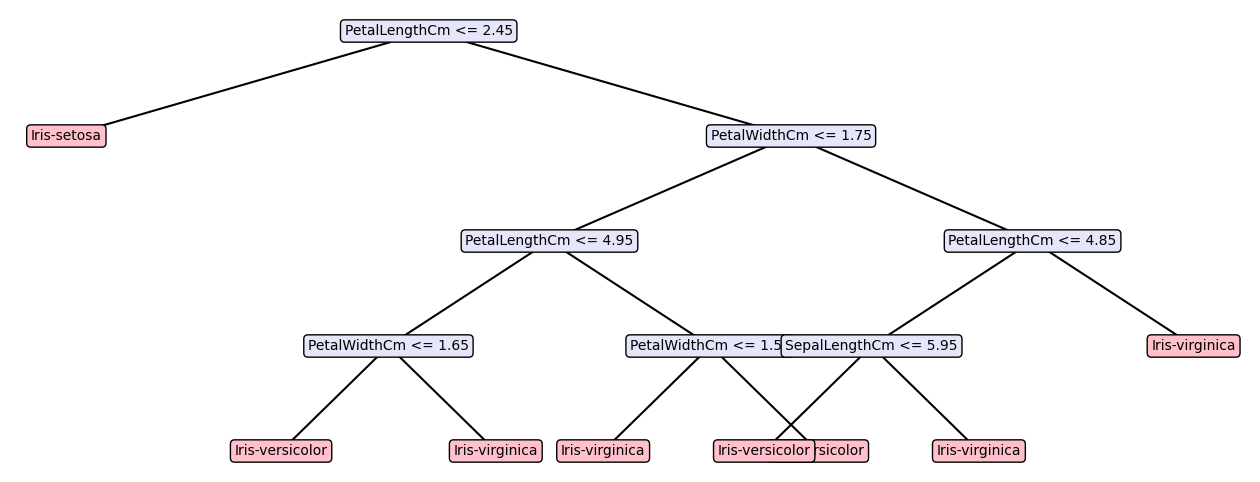

In [9]:
def d_tree(tree, x=0, y=1, dx=0.5, dy=0.2):
    if not isinstance(tree, dict):
        plt.text(x, y, str(tree), ha='center', va='center',
                 bbox=dict(boxstyle="round", fc="pink"))
        return

    key = list(tree.keys())[0]
    plt.text(x, y, key, ha='center', va='center',
             bbox=dict(boxstyle="round", fc="lavender"))

    left = tree[key]["True"]
    right = tree[key]["False"]

    plt.plot([x, x - dx], [y, y - dy], 'k-')
    d_tree(left, x - dx, y - dy, dx/1.5, dy)

    plt.plot([x, x + dx], [y, y - dy], 'k-')
    d_tree(right, x + dx, y - dy, dx/1.5, dy)

plt.figure(figsize=(16, 6))
d_tree(tree)
plt.axis('off')
plt.show()